#### The regression maps of vertical wind shear (wind differences between 850 hPa and 200 hPa levels, m/s) anomalies and  500 hPa Steering anomalies onto the normalized N34, ELI and ELIx index

- Read/Calculate monthly ERA5 850, 500 and 200hpa hPa U, V
- Read Nino34 1980-2022
- Calculate wind shear between 200 and 850 hPa
- Regression: wind shear and 500 hPa steering onto Niño-3.4, ELI and ELIx
    - 1980-2023
    - 1980-1989
    - 1990-2004
    - 2005-2019
 

      
Reference: Figs 5-8 of the following paper: <br>
https://www.jstage.jst.go.jp/article/jmsj/99/4/99_2021-051/_html/-char/en <br>
The correlation between the ENSO Modoki index and TC frequency over the WNP is <br>
- weak during 1975–1989, 
- strong and significant during 1990–2004, 
- weak again during 2005–2019.

#### Notes:
Use xr.apply_ufunc to write a simple 1D NumPy function, then automatically apply it along a named dimension across an entire xarray object. <br>
(conceptually without explicit Python loops) <br>
    
xr.apply_ufunc is <br>
- cleaner & safer
- dimension-aware: preserving xarray dims & coords
- dask-parallelizable

Use xr.apply_ufunc when:
- math is 1D (regression, correlation, filtering)
- data is ND with labeled dimensions
- avoid manual loops

NOTE: in 500 hPa steering regression, use   <br>
- vec_sig = u_sig & v_sig <br>
 or less strict 
-  vec_sig = u_sig | v_sig

  
Ming Ge Feb 2026

In [1]:
import os
import glob
from pathlib import Path
import xarray as xr
import numpy as np
import calendar
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

In [2]:
from scipy.stats import linregress
def regress_and_p(y, x):
    mask = np.isfinite(y) & np.isfinite(x)
    if mask.sum() < 3:
        return np.nan, np.nan

    res = linregress(x[mask], y[mask])
    return res.slope, res.pvalue


In [11]:
def plot_regression(da, sig, var, time_s):
    '''

    '''
    fig = plt.figure(figsize=(10,4))
    #Pacific-centered ENSO map.
    ax = plt.axes(
        projection=ccrs.PlateCarree(central_longitude=180)
    )
    #print(da.month)
    # regression map
    im = ax.pcolormesh(
        da.longitude,
        da.latitude,
        da, #.mean(dim="month"),
        cmap="RdBu_r",
        vmin = -5, vmax=5,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    # Thin and overlay black crosses
    stride = 20

    sig_thin = sig.copy()
    sig_thin[:] = False
    sig_thin[::stride, ::stride] = sig[::stride, ::stride]

    lat2d, lon2d = np.meshgrid(da.latitude, da.longitude, indexing="ij")
    y_idx, x_idx = np.where(sig_thin)

    ax.scatter(
        lon2d[y_idx, x_idx],
        lat2d[y_idx, x_idx],
        s=8,
        c="k",
        marker="x",
        linewidths=0.3,
        transform=ccrs.PlateCarree()
    )

    # Add coastlines & formatting
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.set_title( var + '  ' + time_s  + "\n" + 
                 " (Black crosses: p < 0.05) " )

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        alpha=0.6,
        linestyle="--"
    )

    # show labels only on left & bottom
    gl.top_labels = False
    gl.right_labels = False

    # control tick locations
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))

    # formatting
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

    #plt.colorbar(im, ax=ax, shrink=0.6)
    plt.colorbar(im, ax=ax,orientation="horizontal",shrink=0.4)
    
    plt.tight_layout()
    plt.show()

In [4]:

# Apply regression along “month” axis
# sst: (month, nx, ny)
# n34: (month,)

# Regression slope map by using xr.apply_ufunc:
# Apply a normal NumPy function along the month dimension 
# at every grid point, while keeping xarray’s labeled dimensions.

def regression_plot_3p(da, n34_da, eli_da, elix_da, time_s):
    # list of predictors and names
    predictors = [
        (n34_da,  "N34"),
        (eli_da,  "ELI"),
        (elix_da,  "ELIx"),
    ]

    for idx_da, name in predictors:
        print(name)
        # ensure correct dimension name
        if "month" not in idx_da.dims:
            idx_da = idx_da.rename({idx_da.dims[0]: "month"})

        # regression + p-value
        sst_reg, sst_p = xr.apply_ufunc(
            regress_and_p,
            da,          # SST (month, lat, lon) or (month, nx, ny)
            idx_da,      # index (month)
            input_core_dims=[["month"], ["month"]],
            output_core_dims=[[], []],
            vectorize=True,
            output_dtypes=[float, float],
        )

        # significance mask
        sig = sst_p < 0.05

        # plot
        plot_regression(sst_reg, sig, name, time_s)

In [5]:

# Apply regression along “month” axis
# sst: (month, nx, ny)
# n34: (month,)

# Regression slope map by using xr.apply_ufunc:
# Apply a normal NumPy function along the month dimension 
# at every grid point, while keeping xarray’s labeled dimensions.

def regression_VecPlot_3p(da_u, da_v, n34_da, eli_da, elix_da, time_s):
    # list of predictors and names
    predictors = [
        (n34_da,  "N34"),
        (eli_da,  "ELI"),
        (elix_da,  "ELIx"),
    ]

    for idx_da, name in predictors:
        print(name)
        # ensure correct dimension name
        if "month" not in idx_da.dims:
            idx_da = idx_da.rename({idx_da.dims[0]: "month"})

        # regression + p-value
        u_reg, u_p = xr.apply_ufunc(
            regress_and_p,
            da_u,          # SST (month, lat, lon) or (month, nx, ny)
            idx_da,      # index (month)
            input_core_dims=[["month"], ["month"]],
            output_core_dims=[[], []],
            vectorize=True,
            output_dtypes=[float, float],
        )

        # regression + p-value
        v_reg, v_p = xr.apply_ufunc(
            regress_and_p,
            da_v,          # SST (month, lat, lon) or (month, nx, ny)
            idx_da,      # index (month)
            input_core_dims=[["month"], ["month"]],
            output_core_dims=[[], []],
            vectorize=True,
            output_dtypes=[float, float],
        )

        #speed_reg = np.sqrt(u_reg**2 + v_reg**2)
        
        # significance mask
        u_sig = u_p < 0.05
        v_sig = v_p < 0.05
        vec_sig = u_sig & v_sig
        # less strict
        #vec_sig = u_sig | v_sig

        # plot
        plot_regression_vec(u_reg, v_reg, vec_sig, name, time_s)

#regression_VecPlot_3p(u_500_anom, v_500_anom, n34_anom, eli_anom, elix_anom, '1980-2022')

In [27]:
def plot_regression_vec(u_reg, v_reg, vec_sig, var, time_s):
    '''

    '''
    fig = plt.figure(figsize=(10,4))
    
    ax = plt.axes(
        projection=ccrs.PlateCarree(central_longitude=180)
    )

    # Plot with masked vectors
    u_plot = u_reg.where(vec_sig)
    v_plot = v_reg.where(vec_sig)

    # Thin and overlay vectors
    stride = 20

    # stride coordinates
    lon_sub = u_reg.longitude.isel(longitude=slice(None, None, stride)).values
    lat_sub = u_reg.latitude.isel(latitude=slice(None, None, stride)).values

    # stride vectors
    u_sub = u_reg.isel(latitude=slice(None, None, stride),
                   longitude=slice(None, None, stride)).values
    v_sub = v_reg.isel(latitude=slice(None, None, stride),
                   longitude=slice(None, None, stride)).values

    # stride significant vectors
    u_sig_sub = u_plot.isel(latitude=slice(None, None, stride),
                        longitude=slice(None, None, stride)).values

    v_sig_sub = v_plot.isel(latitude=slice(None, None, stride),
                        longitude=slice(None, None, stride)).values

    lon2d, lat2d = np.meshgrid(lon_sub, lat_sub)

    
    # all vectors (light gray)
    ax.quiver(
        lon2d, lat2d,
        u_sub, v_sub,
        color="lightgray",
        transform=ccrs.PlateCarree(),
        scale=30)

    ax.quiver(
        lon2d, lat2d,
        u_sig_sub, v_sig_sub,
        color="k",
        transform=ccrs.PlateCarree(),
        scale=30)
     
    # Add coastlines & formatting
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.set_title( var + '  ' + time_s  + "\n" + 
                 " (Black significant vectors: p < 0.05) " )

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        alpha=0.6,
        linestyle="--"
    )

    # show labels only on left & bottom
    gl.top_labels = False
    gl.right_labels = False

    # control tick locations
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))

    # formatting
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

    plt.tight_layout()
    plt.show()


#### Setup
Niño-3.4 region: 5°S–5°N, 170°W–120°W

In [6]:
# Monthly ERA5 end in 2022
year_s = 1980
year_e = 2022
n_year = year_e - year_s + 1

month_1d = ['01','02','03','04','05','06','07','08', '09', '10', '11', '12']

#### Read ERA5 850,500 and 200 hPa U and V

In [7]:
%%time

dir_o = '/glade/campaign/mmm/c3we/mingge/ERA5/UV/'
dir_uv = '/glade/campaign/collections/rda/data/d633001/e5.moda.an.pl/'
 
var = ['u','v']
n_var = len(var)
levels = [200,500, 850]

for nv in range(n_var):
  monthly_all = []
  flnm_o = dir_o + var[nv] + '_monthly_era5_1980-2022.nc'  
  if not os.path.exists(flnm_o):
    for year in range(year_s, year_e + 1):
        year = str(year)
        dir_w = dir_uv + year + '/'

        # get all January files
        if var[nv]== 'u':
            flnm = dir_w + 'e5.moda.an.pl.128_131_u.ll025uv.' + year + '010100_'+ year + '120100.nc'
        else:
            flnm = dir_w + 'e5.moda.an.pl.128_132_v.ll025uv.' + year + '010100_'+ year + '120100.nc'
        print(flnm)

        # open lazily with chunking
        ds = xr.open_dataset(flnm)
                 
        # select 500 hPa
        if var[nv]== 'u':
            u500 = ds['U'].sel(level=levels)
        else:
            u500 = ds['V'].sel(level=levels)

        monthly_all.append(u500)
         
    u500_month = xr.concat(monthly_all, dim="time")
    print(flnm_o)
    u500_month.to_netcdf(flnm_o)
 

CPU times: user 0 ns, sys: 1.33 ms, total: 1.33 ms
Wall time: 2.44 ms


#### Calculate shear of 200 and 850 hPa wind

In [8]:
%%time
flnm = dir_o + 'u_monthly_era5_1980-2022.nc' 
ds = xr.open_dataset(flnm)
u_200 = ds['U'].sel(level=200) #.sel(time=slice("1980-01-01", "2003-12-31"))
u_850 = ds['U'].sel(level=850) #.sel(time=slice("1980-01-01", "2003-12-31"))
 
flnm = dir_o + 'v_monthly_era5_1980-2022.nc' 
ds = xr.open_dataset(flnm)
v_200 = ds['V'].sel(level=200) #.sel(time=slice("1980-01-01", "2003-12-31"))
v_850 = ds['V'].sel(level=850) #.sel(time=slice("1980-01-01", "2003-12-31"))

shear = np.sqrt((u_200-u_850)**2 + (v_200 - v_850)**2)
shear.name = "shear_200_850"
shear = shear.rename({"time": "month"}) 

CPU times: user 30.5 s, sys: 3.32 s, total: 33.8 s
Wall time: 50.4 s


#### Read Nino34 1980-2023

In [10]:
#Column 1: Month
#Column 2: A day index
#Column 3: The Nino34 index values
#Column 4 values (ELI),
#Column 7 values (ELIx)  
dir_sst = '/glade/campaign/mmm/c3we/mingge/ERA5/SST/'
flnm_nino = dir_sst + 'Book32p120_DbD_ELIx.txt'
month, N34, ELI, year, ELIx = np.loadtxt(flnm_nino,
    usecols=(0,2,3,5,6), unpack=True)

# Make DataFrame
df = pd.DataFrame({
    "year": year.astype(int),
    "month": month.astype(int),
    "N34": N34,
    "ELI": ELI,
    "ELIx": ELIx
})

df_sel = df[
    (df["year"] >= 1980) &
    (df["year"] <= 2022)
]

# Group by year and month, then take mean
#monthly_mean_per_year = df.groupby(["year", "month"])[["N34", "ELI", "ELIx"]].mean()
monthly_mean_per_year = (
    df_sel.groupby(["year", "month"])[["N34", "ELI", "ELIx"]]
      .mean()
      .reset_index()
)

# because n34 data is from April 1980, I add three nan
n34 = np.concatenate([np.full(3, np.nan), monthly_mean_per_year.N34.values])
#month_1d = np.concatenate([[198001,198002,198003], monthly_mean_per_year.month +monthly_mean_per_year.year*100])
# shares the same month coordinates as your SSTK DataArray
n34_da = xr.DataArray(
    n34,
    dims="month",
    coords={"month": shear.month},  # copy month coordinates
    name="N34"
)
# Convert n34 to DataArray  
#n34_da = xr.DataArray(n34, dims="month")

eli = np.concatenate([np.full(3, np.nan), monthly_mean_per_year.ELI.values])
#eli_da = xr.DataArray(eli, dims="month")
eli_da = xr.DataArray(
    eli,
    dims="month",
    coords={"month": shear.month},  # copy month coordinates
    name="N34"
)

elix = np.concatenate([np.full(3, np.nan), monthly_mean_per_year.ELIx.values])
#elix_da = xr.DataArray(elix, dims="month")
elix_da = xr.DataArray(
    elix,
    dims="month",
    coords={"month":shear.month},  # copy month coordinates
    name="N34"
)
#len(monthly_mean_per_year.N34.values), monthly_mean_per_year

#### The regression map of vertical wind shear (wind differences between 850 hPa and 200 hPa levels, m/s) anomalies onto the normalized N34, ELI and ELIx index
- 1980-2022

N34


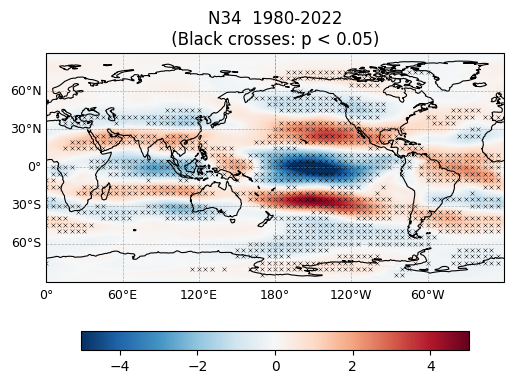

ELI


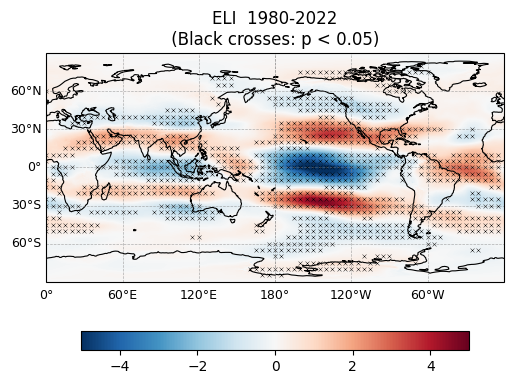

ELIx


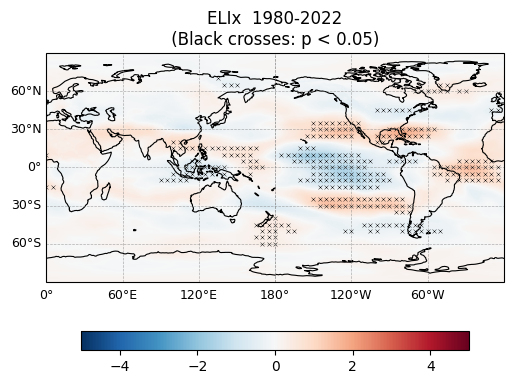

In [13]:
shear_anom = shear - shear.mean(dim="month")

n34_anom = n34_da - n34_da.mean(dim="month")
eli_anom = eli_da - eli_da.mean(dim="month")
elix_anom = elix_da - elix_da.mean(dim="month")
 
regression_plot_3p(shear_anom, n34_anom, eli_anom, elix_anom, '1980-2022')

#### Regression: Shear onto Niño-3.4, ELI and ELIx (1980–1989)

N34


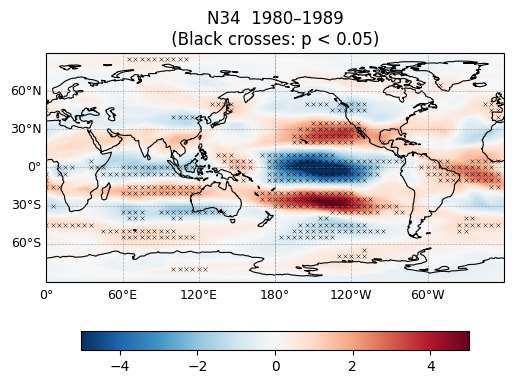

ELI


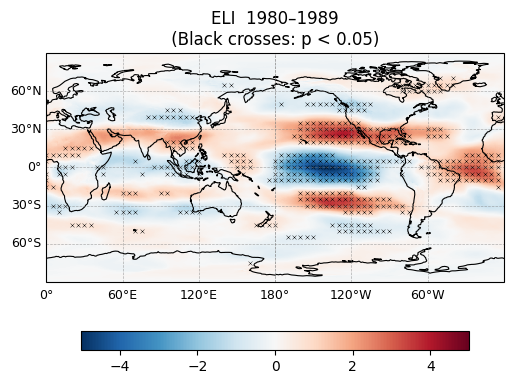

ELIx


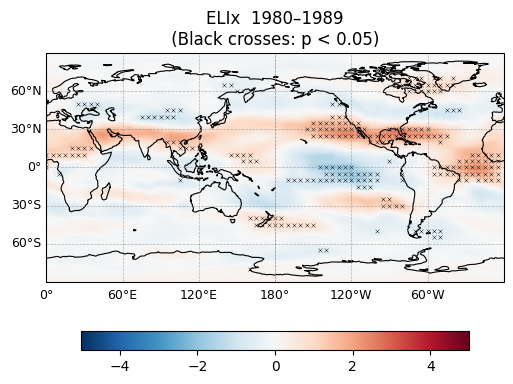

In [14]:
shear_select = shear.sel(month=slice("1980-01-01", "1989-12-31"))
shear_anom   = shear_select - shear_select.mean(dim="month")

n34_anom = n34_da.sel(month=slice("1980-01-01", "1989-12-31")) - \
            n34_da.sel(month=slice("1980-01-01", "1989-12-31")).mean(dim="month")

eli_anom = eli_da.sel(month=slice("1980-01-01", "1989-12-31")) - \
            eli_da.sel(month=slice("1980-01-01", "1989-12-31")).mean(dim="month")

elix_anom = elix_da.sel(month=slice("1980-01-01", "1989-12-31")) - \
            elix_da.sel(month=slice("1980-01-01", "1989-12-31")).mean(dim="month")
regression_plot_3p(shear_anom, n34_anom, eli_anom, elix_anom, '1980–1989')

#### Regression: Shear onto Niño-3.4, ELI and ELIx (1990–2004)

N34


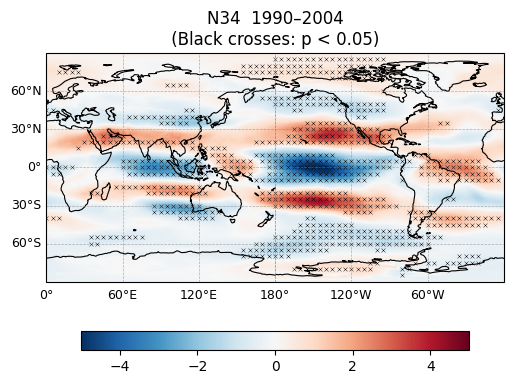

ELI


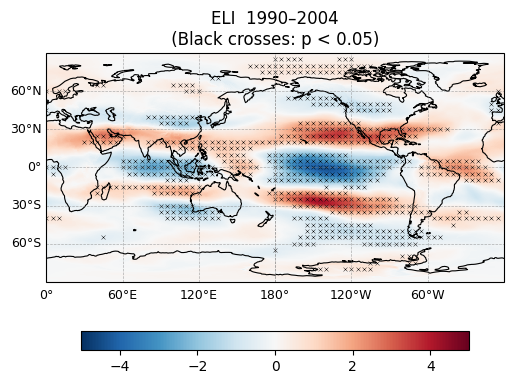

ELIx


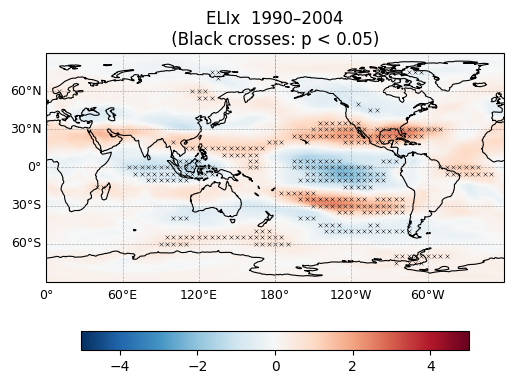

In [15]:
shear_anom = shear.sel(month=slice("1990-01-01", "2004-12-31")) - \
             shear.sel(month=slice("1990-01-01", "2004-12-31")).mean(dim="month")

n34_anom = n34_da.sel(month=slice("1990-01-01", "2004-12-31")) - \
            n34_da.sel(month=slice("1990-01-01", "2004-12-31")).mean(dim="month")

eli_anom = eli_da.sel(month=slice("1990-01-01", "2004-12-31")) - \
            eli_da.sel(month=slice("1990-01-01", "2004-12-31")).mean(dim="month")

elix_anom = elix_da.sel(month=slice("1990-01-01", "2004-12-31")) - \
            elix_da.sel(month=slice("1990-01-01", "2004-12-31")).mean(dim="month")
regression_plot_3p(shear_anom, n34_anom, eli_anom, elix_anom, '1990–2004')


#### Regression: Shear onto Niño-3.4, ELI and ELIx (2005–2019)

N34


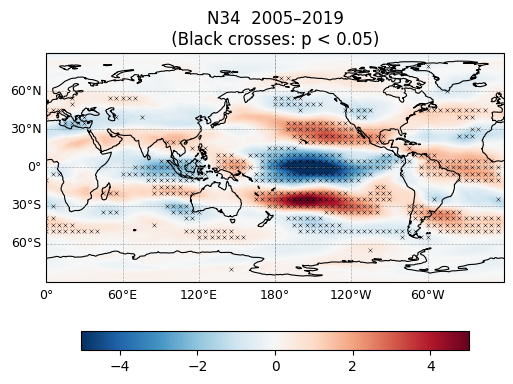

ELI


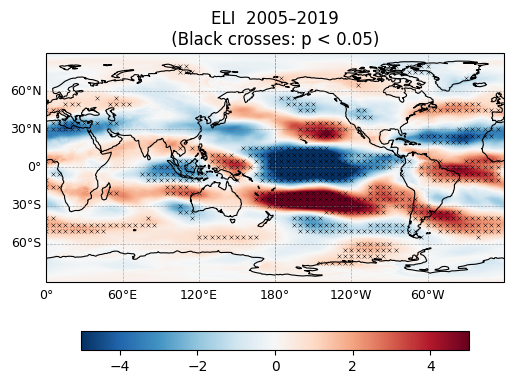

ELIx


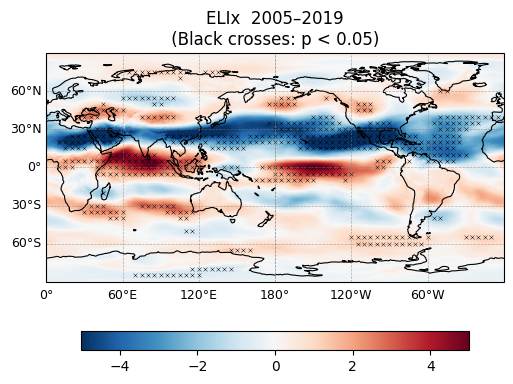

In [16]:
shear_anom = shear.sel(month=slice("2005-01-01", "2019-12-31")) - \
             shear.sel(month=slice("2005-01-01", "2019-12-31")).mean(dim="month")

n34_anom = n34_da.sel(month=slice("2005-01-01", "2019-12-31")) - \
            n34_da.sel(month=slice("2005-01-01", "2019-12-31")).mean(dim="month")

eli_anom = eli_da.sel(month=slice("2005-01-01", "2019-12-31")) - \
            eli_da.sel(month=slice("2005-01-01", "2019-12-31")).mean(dim="month")

elix_anom = elix_da.sel(month=slice("2005-01-01", "2019-12-31")) - \
            elix_da.sel(month=slice("2005-01-01", "2019-12-31")).mean(dim="month")
regression_plot_3p(shear_anom, n34_anom, eli_anom, elix_anom, '2005–2019')

#### The regression map of steering wind of 500 hPa anomalies onto the normalized N34, ELI and ELIx index
- 1980-2022

In [25]:
%%time
flnm = dir_o + 'u_monthly_era5_1980-2022.nc' 
ds_u = xr.open_dataset(flnm)
u_500 = ds_u['U'].sel(level=500) #.sel(time=slice("1980-01-01", "2003-12-31"))
  
flnm = dir_o + 'v_monthly_era5_1980-2022.nc' 
ds_v = xr.open_dataset(flnm)
v_500 = ds_v['V'].sel(level=500) #.sel(time=slice("1980-01-01", "2003-12-31"))
 
u_500 = u_500.rename({"time": "month"}) 
v_500 = v_500.rename({"time": "month"}) 

CPU times: user 17.1 ms, sys: 10.5 ms, total: 27.7 ms
Wall time: 120 ms


N34


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


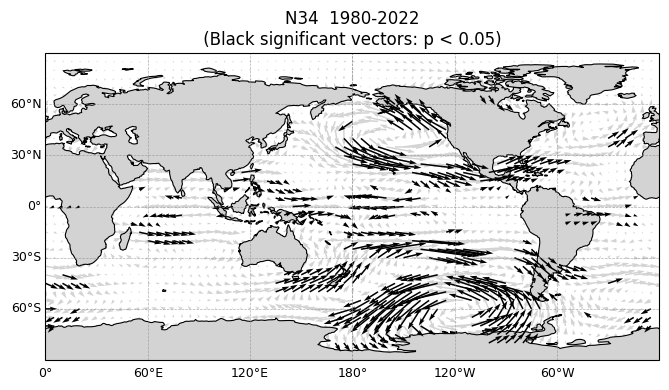

ELI


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


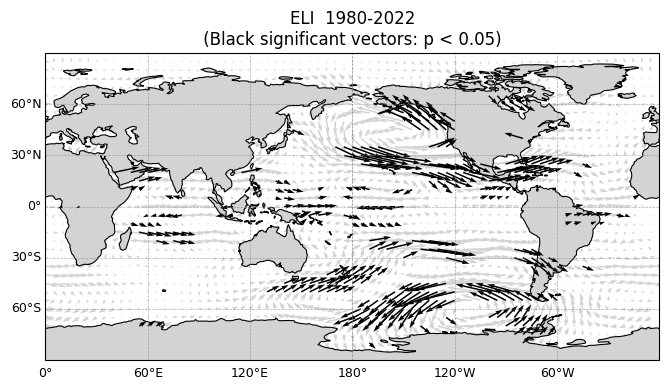

ELIx


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


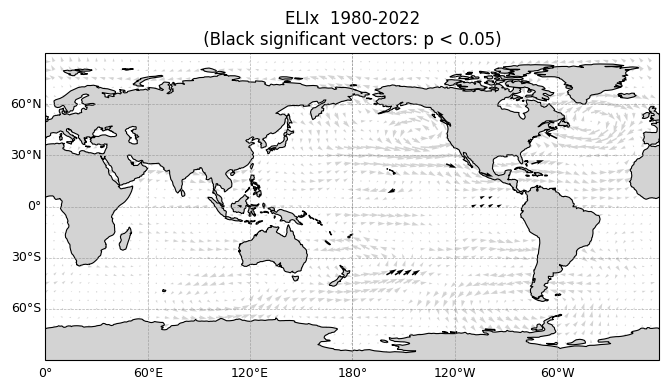

In [28]:
u_500_anom = u_500 - u_500.mean(dim="month")
v_500_anom = v_500 - v_500.mean(dim="month")

n34_anom = n34_da - n34_da.mean(dim="month")
eli_anom = eli_da - eli_da.mean(dim="month")
elix_anom = elix_da - elix_da.mean(dim="month")
 
regression_VecPlot_3p(u_500_anom, v_500_anom, n34_anom, eli_anom, elix_anom, '1980-2022')

#### 1980–1989

N34


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


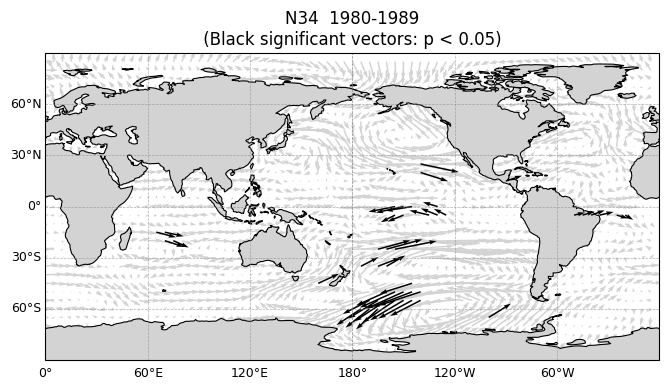

ELI


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


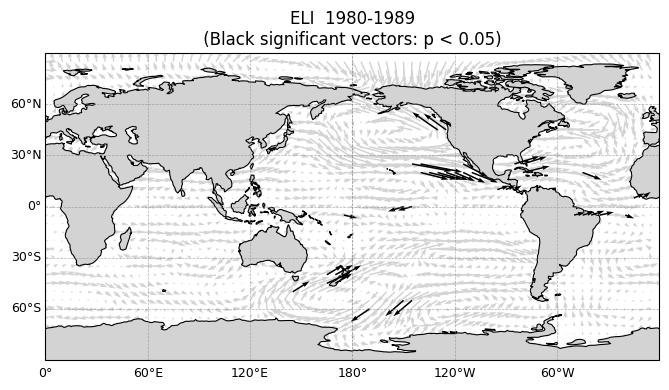

ELIx


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


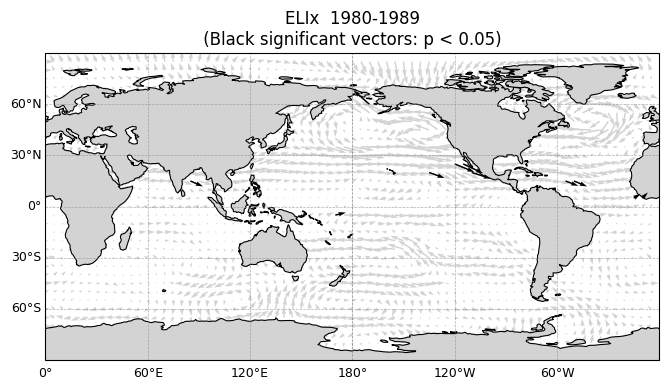

In [29]:
u_500 = ds_u['U'].sel(level=500).sel(time=slice("1980-01-01", "1989-12-31"))
v_500 = ds_v['V'].sel(level=500).sel(time=slice("1980-01-01", "1989-12-31"))
 
u_500 = u_500.rename({"time": "month"}) 
v_500 = v_500.rename({"time": "month"}) 

u_500_anom = u_500 - u_500.mean(dim="month")
v_500_anom = v_500 - v_500.mean(dim="month")

n34_anom = n34_da.sel(month=slice("1980-01-01", "1989-12-31")) - \
            n34_da.sel(month=slice("1980-01-01", "1989-12-31")).mean(dim="month")

eli_anom = eli_da.sel(month=slice("1980-01-01", "1989-12-31")) - \
            eli_da.sel(month=slice("1980-01-01", "1989-12-31")).mean(dim="month")

elix_anom = elix_da.sel(month=slice("1980-01-01", "1989-12-31")) - \
            elix_da.sel(month=slice("1980-01-01", "1989-12-31")).mean(dim="month")
 
regression_VecPlot_3p(u_500_anom, v_500_anom, n34_anom, eli_anom, elix_anom, '1980-1989')

#### 1990–2004

N34


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


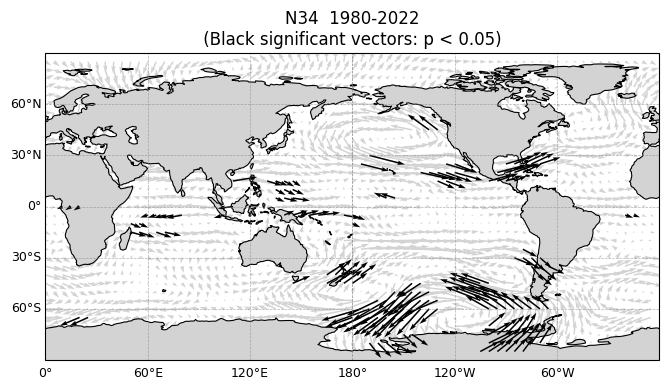

ELI


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


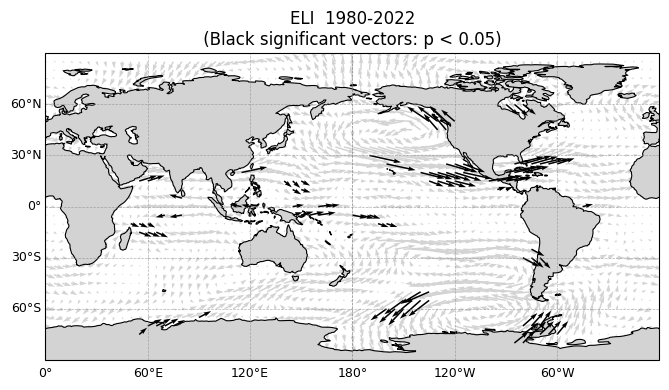

ELIx


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


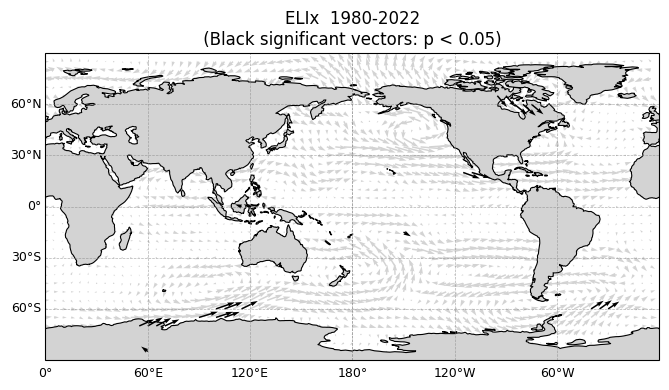

In [30]:
u_500 = ds_u['U'].sel(level=500).sel(time=slice("1990-01-01", "2004-12-31"))
v_500 = ds_v['V'].sel(level=500).sel(time=slice("1990-01-01", "2004-12-31"))
 
u_500 = u_500.rename({"time": "month"}) 
v_500 = v_500.rename({"time": "month"}) 

u_500_anom = u_500 - u_500.mean(dim="month")
v_500_anom = v_500 - v_500.mean(dim="month")

n34_anom = n34_da.sel(month=slice("1990-01-01", "2004-12-31")) - \
            n34_da.sel(month=slice("1990-01-01", "2004-12-31")).mean(dim="month")

eli_anom = eli_da.sel(month=slice("1990-01-01", "2004-12-31")) - \
            eli_da.sel(month=slice("1990-01-01", "2004-12-31")).mean(dim="month")

elix_anom = elix_da.sel(month=slice("1990-01-01", "2004-12-31")) - \
            elix_da.sel(month=slice("1990-01-01", "2004-12-31")).mean(dim="month")

regression_VecPlot_3p(u_500_anom, v_500_anom, n34_anom, eli_anom, elix_anom, '1980-2022')

#### 2005–2019

N34


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


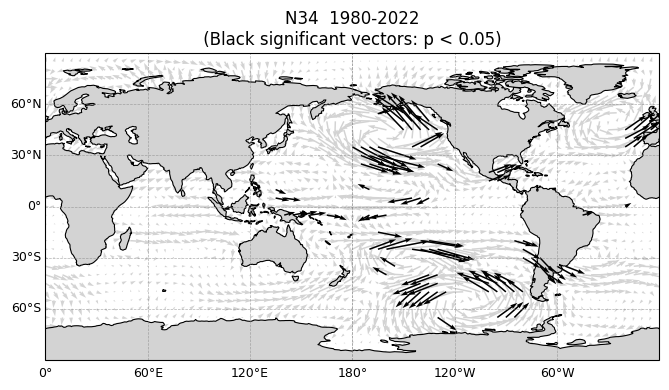

ELI


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


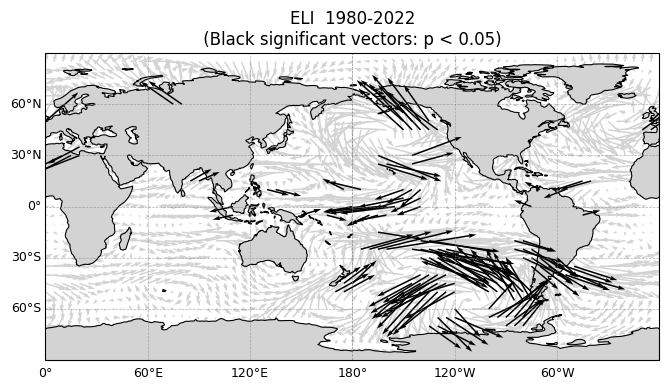

ELIx


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/cartopy/crs.py:538: UserWarning: Some vectors at source domain corners may not have been transformed correctly
  warnings.warn('Some vectors at source domain corners '


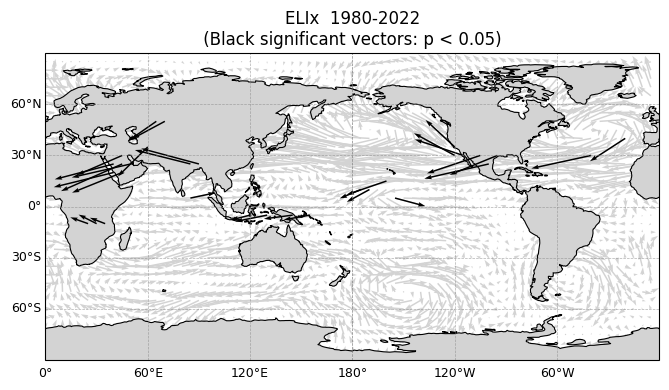

In [31]:
u_500 = ds_u['U'].sel(level=500).sel(time=slice("2005-01-01", "2019-12-31"))
v_500 = ds_v['V'].sel(level=500).sel(time=slice("2005-01-01", "2019-12-31"))
 
u_500 = u_500.rename({"time": "month"}) 
v_500 = v_500.rename({"time": "month"}) 

u_500_anom = u_500 - u_500.mean(dim="month")
v_500_anom = v_500 - v_500.mean(dim="month")

n34_anom = n34_da.sel(month=slice("2005-01-01", "2019-12-31")) - \
            n34_da.sel(month=slice("2005-01-01", "2019-12-31")).mean(dim="month")

eli_anom = eli_da.sel(month=slice("2005-01-01", "2019-12-31")) - \
            eli_da.sel(month=slice("2005-01-01", "2019-12-31")).mean(dim="month")

elix_anom = elix_da.sel(month=slice("2005-01-01", "2019-12-31")) - \
            elix_da.sel(month=slice("2005-01-01", "2019-12-31")).mean(dim="month")

regression_VecPlot_3p(u_500_anom, v_500_anom, n34_anom, eli_anom, elix_anom, '1980-2022')